## Setup

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

## Data Load and Preprocessing

In [78]:
df = pd.read_csv("Breast_cancer_dataset.csv")
df = df[[col for col in df.columns if not 'Unnamed' in col]]
X = df.drop(["diagnosis", "id"], axis=1)
y = df["diagnosis"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
feature_names = X.columns.tolist()
print(f"Classes: {label_encoder.classes_}")
print(f"Encoded as: {np.unique(y_encoded)}")
print(f"Number of features: {len(feature_names)}")

Classes: ['B' 'M']
Encoded as: [0 1]
Number of features: 30


## 1.)

### a

In [79]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)
nb = GaussianNB()
knn_acc = cross_val_score(knn, X, y, cv=skf, scoring="accuracy")
nb_acc = cross_val_score(nb, X, y, cv=skf, scoring="accuracy")

print("Mean kNN:", knn_acc.mean(), "±", knn_acc.std())
print("Mean NB:", nb_acc.mean(), "±", nb_acc.std())

Mean kNN: 0.9350100916006833 ± 0.01961038510464635
Mean NB: 0.9385343890700202 ± 0.023468351296512962


### b

In [80]:
knn_scaled = make_pipeline(MinMaxScaler(), knn)
knn_scaled_acc = cross_val_score(knn_scaled, X, y, cv=folds, scoring="accuracy")

print("Mean kNN (with Min-Max scaling):", knn_scaled_acc.mean(), "±" , knn_scaled_acc.std())

Mean kNN (with Min-Max scaling): 0.9718987734823784 ± 0.017873126240107968


### c

In [81]:
from scipy.stats import ttest_rel

nb_scaled = make_pipeline(MinMaxScaler(), GaussianNB())

nb_scaled_acc = cross_val_score(nb_scaled, X, y, cv=skf, scoring="accuracy")
t_stat, p_value = ttest_rel(knn_scaled_acc, nb_scaled_acc)

print("Mean NB scaled: ", nb_scaled_scores.mean(), "±", nb_scaled_scores.std())
print("\nT test:\nt =", t_stat, ", p-value =", p_value)

Mean NB scaled:  0.9297314081664337 ± 0.019922080470489403

T test:
t = 2.4866066258749115 , p-value = 0.0677300288971868


## 2

## a

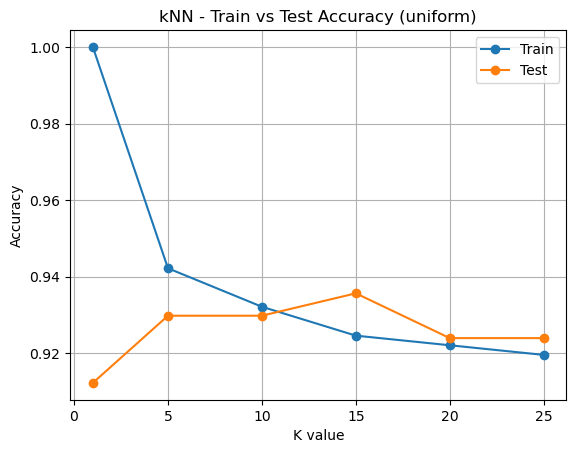

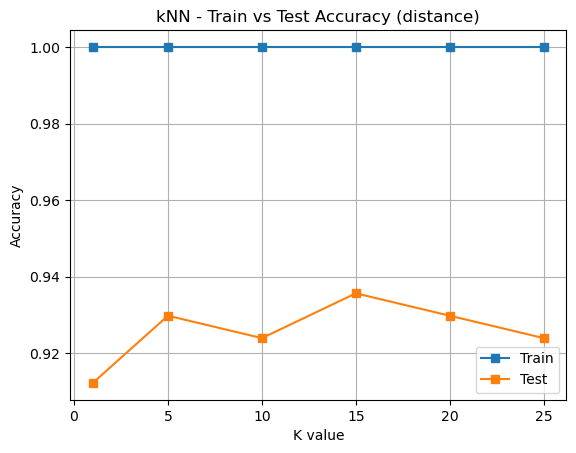

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

k_values = [1, 5, 10, 15, 20, 25]

train_acc_uniform, test_acc_uniform = [], []
train_acc_distance, test_acc_distance = [], []

for k in k_values:
    knn_uniform = KNeighborsClassifier(n_neighbors=k, weights="uniform")
    knn_uniform.fit(X_train, y_train)
    train_acc_uniform.append(knn_uniform.score(X_train, y_train))
    test_acc_uniform.append(knn_uniform.score(X_test, y_test))

    knn_distance = KNeighborsClassifier(n_neighbors=k, weights="distance")
    knn_distance.fit(X_train, y_train)
    train_acc_distance.append(knn_distance.score(X_train, y_train))
    test_acc_distance.append(knn_distance.score(X_test, y_test))
    
plt.plot(k_values, train_acc_uniform, marker="o", label="Train")
plt.plot(k_values, test_acc_uniform, marker="o", label="Test")
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("kNN - Train vs Test Accuracy (uniform)")
plt.legend()
plt.grid(True)
plt.savefig(f'uniform_Weight_Accuracy.png')
plt.show()

plt.plot(k_values, train_acc_distance, marker="s", label="Train")
plt.plot(k_values, test_acc_distance, marker="s", label="Test")
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("kNN - Train vs Test Accuracy (distance)")
plt.legend()
plt.grid(True)
plt.savefig(f'distance_Weight_Accuracy.png')
plt.show()